B.1.1.7 205956
B.1.177 53038
B.1.1 183177
B.1 20819
B.1.1.37 3739
A 402
B.1.1.1 2482
B.1.617.2 265083
AY.4 520652
AY.5 28604
AY.111 5418
AY.122 7567
B 3935
root 0

Tree height: 4.000000
Tree length: 12.000000
multitype tree
annotations present

Numbers of objects in tree: 14 (5 nodes and 9 leaves)



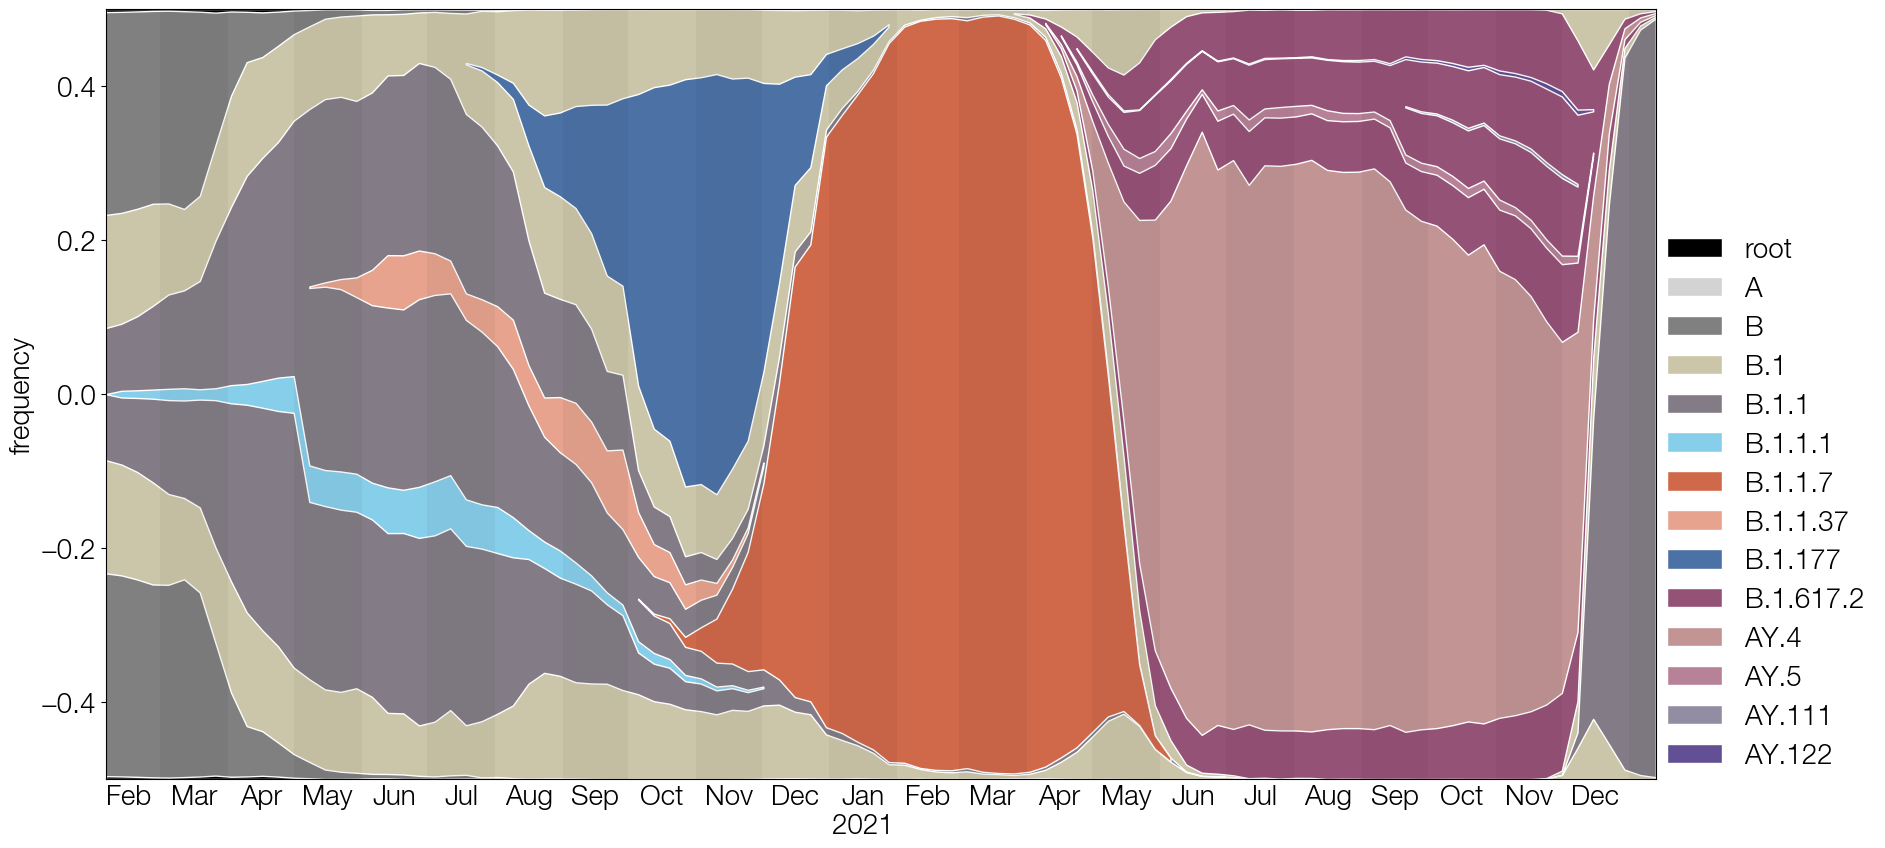

In [1]:
#########
## data taken from: 
## QinQin Yu, Joao Ascensao, Takashi Okada, The COVID-19 Genomics UK (COG-UK) Consortium, Olivia Boyd, Erik Volz, and Oskar Hallatschek. 
## Lineage frequency time series reveal elevated levels of genetic drift in SARS-CoV-2 transmission in England, 
## PLoS Pathogens, 2024. 
## https://journals.plos.org/plospathogens/article?id=10.1371/journal.ppat.1012090
## cog_england_2022-01-16_metadata.csv
#########

import csv, os

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

import baltic as bt
from baltic import bt_utils
from baltic.curonia import make_pivots, tree_frequencies, plot_Muller

#########

basePath = '/mnt/c/Users/evogytis/repos/baltic-v1-manuscript/'

### process summarised data from paper
lineages_freqs = {}
for l in csv.DictReader(open(os.path.join(basePath, 'data/Fig5_Muller/lineage_counts.tsv'), 'r'), delimiter='\t'):
    lineages_freqs[l['lineage']] = {key: int(l[key]) for key in l if key != 'lineage'}

for lin in lineages_freqs:
    print(lin, sum(lineages_freqs[lin].values()))
############

lineage_tree = '(A:1,(((B.1.1.1:1,B.1.1.7:1,B.1.1.37:1)B.1.1:1,B.1.177:1,(AY.4:1,AY.5:1,AY.111:1,AY.122)B.1.617.2:1)B.1:1)B:1)root;' ## abstract lineage tree
ll = bt.make_tree(lineage_tree, 'divergence')
ll.treeStats()

for k in ll.Objects: ## this assigns a trait called "name" which is the lineage's name (e.g. B.1.1.7)
    k.traits['name'] = k.traits['label'] if k.is_node() else k.name

    lineage_freqs = lineages_freqs[k.traits['name']] ## dict of {date: count}
    observations = sum([[bt_utils.calendar_to_decimal_date(date)] * lineage_freqs[date] for date in lineage_freqs], []) ## repeat dates in a list by their count
    
    k.traits['tps'] = observations ## flat list of dates of each genome belonging to this lineage

################
tfe = tree_frequencies(tree=ll, timepoints=100)
tf = tfe.estimate_clade_frequencies() ## estimate clade frequencies, this step takes a long while

#############
fig = plt.figure(figsize=(20, 10), facecolor='w')

gs = GridSpec(1, 1, hspace=0.01, wspace=0.01)
ax=plt.subplot(gs[0])

colours={'A': 'lightgrey', 
         'B': 'grey', 
         'B.1': '#CBC6A9', 
         'B.1.1': '#837C86', 
         'B.1.177': '#4c72a5', 
         'B.1.1.1': '#87CEEB', 
         'B.1.351': '#D79B51', 
         'B.1.620': '#3C6F4A', 
         'B.1.617.2': '#955277', 
         'AY.4': '#C29494', 
         'AY.111': '#938DA3', 
         'AY.122': '#624F94', 
         'AY.5': '#B78197', 
         'B.1.1.7': '#d0694a', 
         'B.1.1.37': '#E7A38D', 
         'root': 'black'}

plot_Muller(ax=ax, node=ll.root, frequenciesDict=tf, timeline=tfe.pivots, labelFxn=lambda k: k.traits['name'], 
            colourFxn=lambda k: colours[k.traits['name']], Muller=True, clipThreshold=0.002, orientation='horizontal')

### add legend
ax.legend(loc=(1.0, 0.0), frameon=False, fontsize=20)

### nice timeline formatting
calendarTimeline = bt_utils.generate_calendar_timeline('2020-01-01', '2022-02-01')
bt_utils.format_time_grid(ax, calendarTimeline)
bt_utils.plot_time_grid(ax, calendarTimeline, zorder=1, alpha=0.04)

### aesthetics
ax.tick_params(labelsize=20)
ax.set_ylabel('frequency', size=20)
ax.set_xlim(min(tfe.pivots), max(tfe.pivots))
ax.set_ylim(-0.5, 0.5)

### save and display
plt.savefig(os.path.join(basePath, 'figures/Fig5_Muller.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(basePath, 'figures/Fig5_Muller.pdf'), dpi=300, bbox_inches='tight')
plt.show()